# Life Expectancy Determinants: Regression and Random Forest Analysis

**Liqi Liang** | Penn MSSP Practical Programming for Data Science (MSSP 6070) | Fall 2024

This project analyzes socioeconomic, health, and environmental determinants of life expectancy across 193 countries (2000–2015) using WHO data. I compare three modeling approaches — OLS linear regression, random forest regression, and an interaction-effects model — to identify key drivers of global health disparities and assess how country development status moderates the effects of education and immunization on life expectancy.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import shapiro

## 2. Data Loading and Cleaning

The WHO Life Expectancy dataset contains 2,938 observations across 193 countries. I remove countries with only one year of data to ensure reliable interpolation, then handle missing values via linear interpolation within country groups, followed by mean imputation for remaining gaps.

In [3]:
LED = pd.read_csv("/content/drive/MyDrive/MSSP-607/Assignments/Final Project/Life Expectancy Data.csv")

In [4]:
LED.shape

(2938, 22)

In [5]:
print(LED.columns)
print(LED.dtypes)
print(LED.isna().sum())

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure    

In [6]:
LED_naall = LED[LED.isna().any(axis=1)]
LED_naall.shape

(1289, 22)

In [7]:
print(LED['Country'].value_counts())
country_counts = LED['Country'].value_counts()
print(country_counts.describe())
countries_not_16 = country_counts[country_counts != 16].index.tolist()
print(countries_not_16)
LED_1_filtered = LED[~LED['Country'].isin(countries_not_16)]
print(LED_1_filtered['Country'].value_counts())

Country
Afghanistan              16
Peru                     16
Nicaragua                16
Niger                    16
Nigeria                  16
                         ..
Niue                      1
San Marino                1
Nauru                     1
Saint Kitts and Nevis     1
Dominica                  1
Name: count, Length: 193, dtype: int64
count    193.000000
mean      15.222798
std        3.333401
min        1.000000
25%       16.000000
50%       16.000000
75%       16.000000
max       16.000000
Name: count, dtype: float64
['Tuvalu', 'Cook Islands', 'Marshall Islands', 'Monaco', 'Palau', 'Niue', 'San Marino', 'Nauru', 'Saint Kitts and Nevis', 'Dominica']
Country
Afghanistan    16
New Zealand    16
Niger          16
Nigeria        16
Norway         16
               ..
Ghana          16
Greece         16
Grenada        16
Guatemala      16
Zimbabwe       16
Name: count, Length: 183, dtype: int64


In [8]:
def fill_na(group):
    columns_to_fill = [
        'Life expectancy','Adult Mortality', 'Alcohol', 'Hepatitis B', 'BMI', 'Polio',
        'Total expenditure', 'Diphtheria', 'GDP', 'Population',
        'thinness  1-19 years', 'thinness 5-9 years',
        'Income composition of resources', 'Schooling'
    ]

    for col in columns_to_fill:
        if col in group.columns:
            group[col] = group[col].interpolate(method='linear', limit_direction='both', axis=0)
            group[col] = group[col].fillna(method='ffill').fillna(method='bfill')
    return group

LED_2_filled = LED_1_filtered.groupby('Country', group_keys=False).apply(fill_na)
print(LED_2_filled.isna().sum())

<ipython-input-8-18e7e845cbef>:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group[col] = group[col].fillna(method='ffill').fillna(method='bfill')


Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                             16
percentage expenditure               0
Hepatitis B                        144
Measles                              0
 BMI                                32
under-five deaths                    0
Polio                                0
Total expenditure                   32
Diphtheria                          19
 HIV/AIDS                            0
GDP                                400
Population                         640
 thinness  1-19 years               32
 thinness 5-9 years                 32
Income composition of resources    160
Schooling                          160
dtype: int64


<ipython-input-8-18e7e845cbef>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  LED_2_filled = LED_1_filtered.groupby('Country', group_keys=False).apply(fill_na)


In [9]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean', fill_value=None)

LED_2_filled['Alcohol']=imputer.fit_transform(LED_2_filled[['Alcohol']])
LED_2_filled['Hepatitis B']=imputer.fit_transform(LED_2_filled[['Hepatitis B']])
LED_2_filled[' BMI ']=imputer.fit_transform(LED_2_filled[[' BMI ']])
LED_2_filled['Total expenditure']=imputer.fit_transform(LED_2_filled[['Total expenditure']])
LED_2_filled['Diphtheria ']=imputer.fit_transform(LED_2_filled[['Diphtheria ']])
LED_2_filled['GDP']=imputer.fit_transform(LED_2_filled[['GDP']])
LED_2_filled['Population']=imputer.fit_transform(LED_2_filled[['Population']])
LED_2_filled[' thinness  1-19 years']=imputer.fit_transform(LED_2_filled[[' thinness  1-19 years']])
LED_2_filled[' thinness 5-9 years']=imputer.fit_transform(LED_2_filled[[' thinness 5-9 years']])
LED_2_filled['Income composition of resources']=imputer.fit_transform(LED_2_filled[['Income composition of resources']])
LED_2_filled['Schooling']=imputer.fit_transform(LED_2_filled[['Schooling']])

In [10]:
LEDC = LED_2_filled
print(LEDC.isna().sum())

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64


## 3. Exploratory Data Analysis

I examine distributional properties (normality, skewness, kurtosis), visualize life expectancy patterns by development status and over time, and assess variable correlations and multicollinearity before modeling.

### 3.1 Descriptive Statistics

In [11]:
print(LEDC.describe())

             Year  Life expectancy   Adult Mortality  infant deaths  \
count  2928.00000       2928.000000      2928.000000    2928.000000   
mean   2007.50000         69.224932       164.796448      30.407445   
std       4.61056          9.523867       124.292079     118.114450   
min    2000.00000         36.300000         1.000000       0.000000   
25%    2003.75000         63.100000        74.000000       0.000000   
50%    2007.50000         72.100000       144.000000       3.000000   
75%    2011.25000         75.700000       228.000000      22.000000   
max    2015.00000         89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B       Measles   \
count  2928.000000             2928.000000  2928.000000    2928.000000   
mean      4.528796              740.321185    75.815374    2427.855874   
std       4.058530             1990.930605    27.880811   11485.970937   
min       0.010000                0.000000     1.000000       0.

### 3.2 Distributional Analysis

Histograms and QQ plots reveal that most variables deviate from normality. Key variables like Population (skewness = 18.0) and infant deaths (skewness = 9.77) are highly skewed, reflecting global disparities. These distributions are preserved as they represent real-world variation rather than data error.

In [12]:
print(LEDC.dtypes)

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object


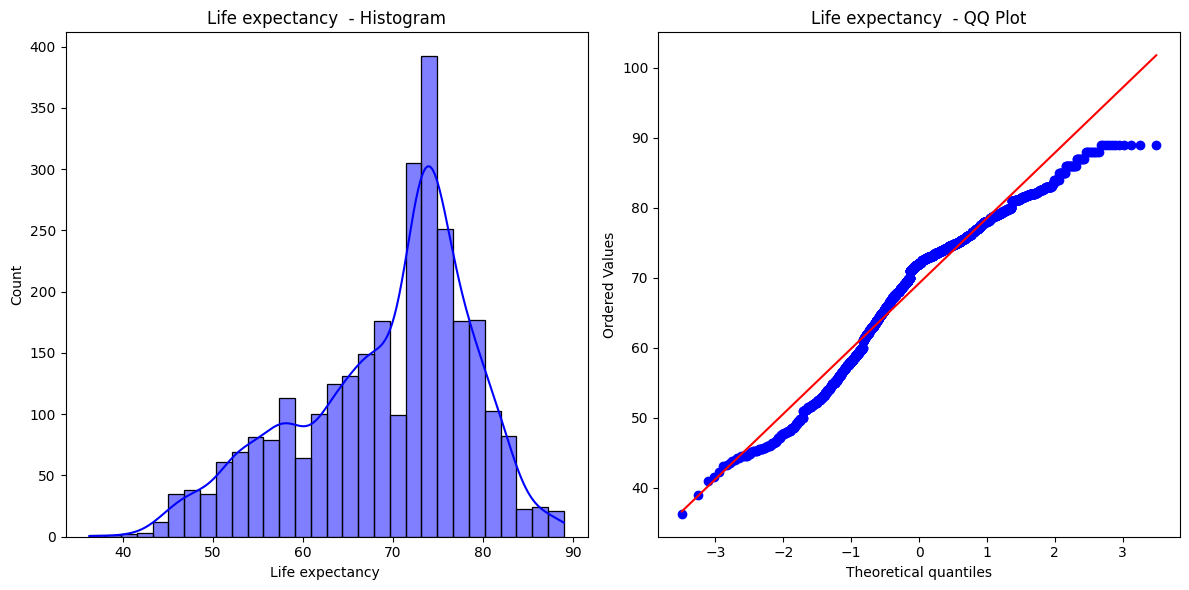

Variable: Life expectancy 
  Skewness: -0.638
  Kurtosis: -0.236
  Shapiro-Wilk Test Statistic: 0.956, p-value: 0.000
--------------------------------------------------


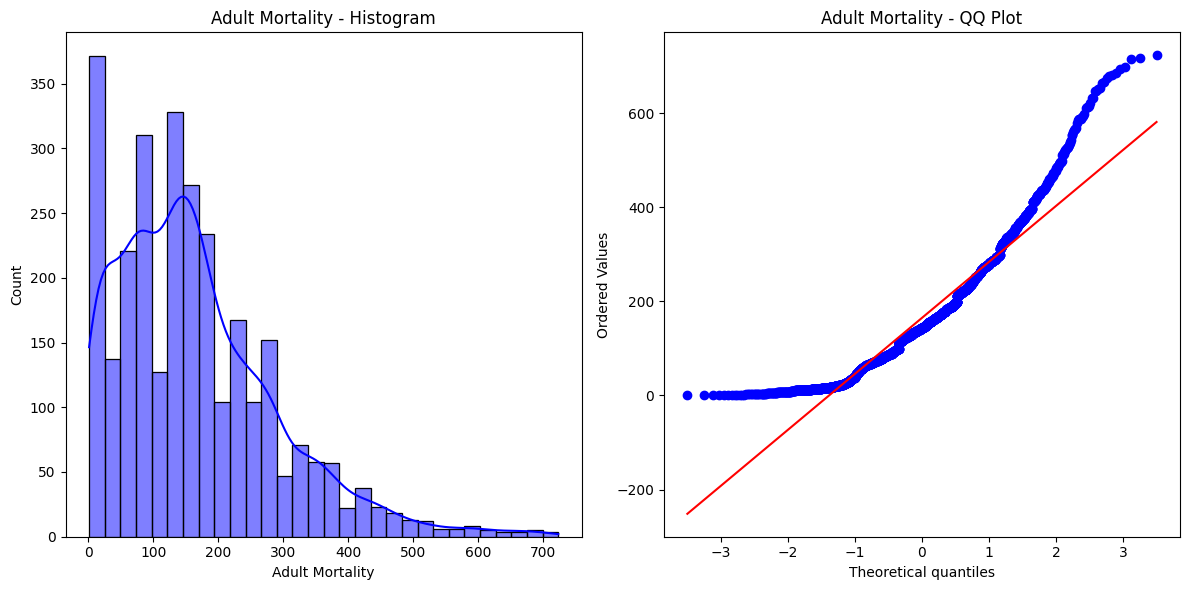

Variable: Adult Mortality
  Skewness: 1.174
  Kurtosis: 1.744
  Shapiro-Wilk Test Statistic: 0.917, p-value: 0.000
--------------------------------------------------


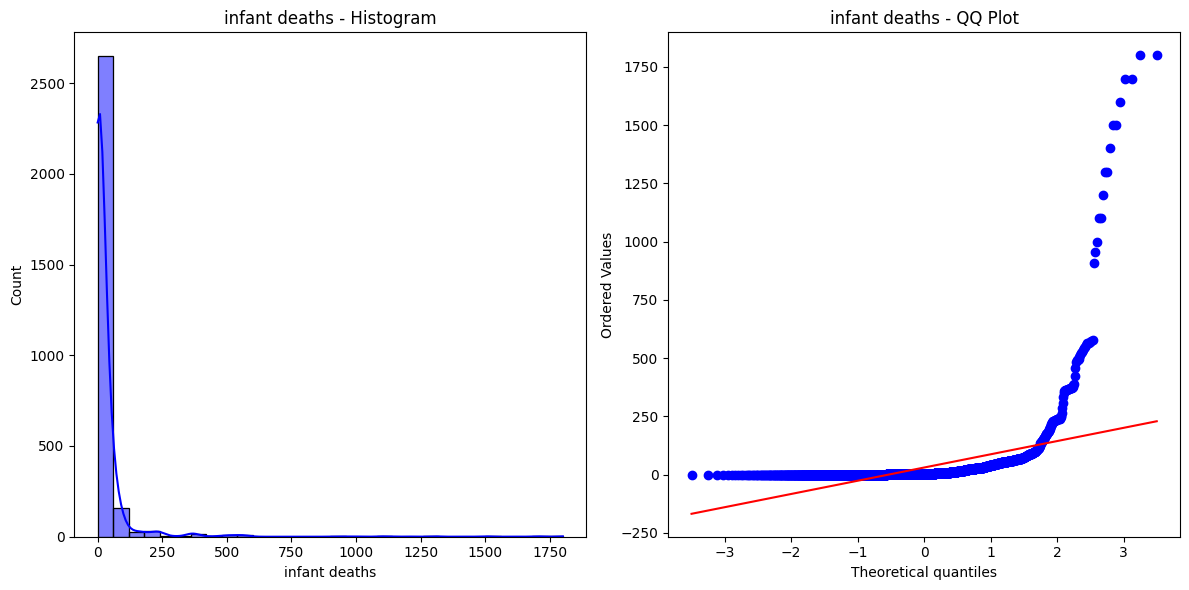

Variable: infant deaths
  Skewness: 9.766
  Kurtosis: 115.458
  Shapiro-Wilk Test Statistic: 0.232, p-value: 0.000
--------------------------------------------------


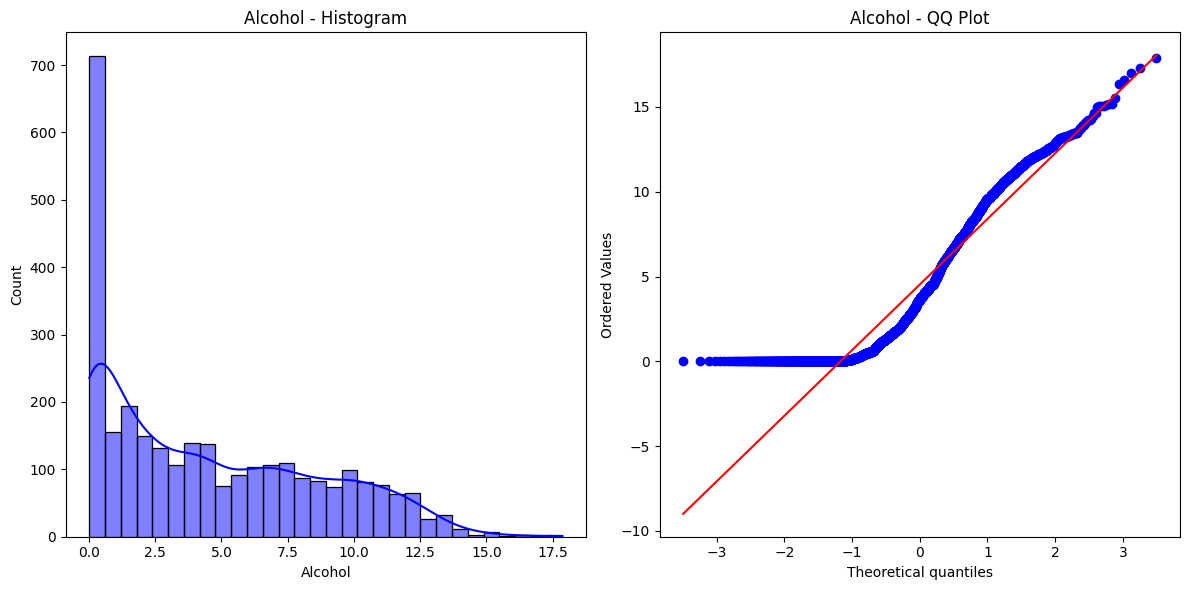

Variable: Alcohol
  Skewness: 0.602
  Kurtosis: -0.790
  Shapiro-Wilk Test Statistic: 0.906, p-value: 0.000
--------------------------------------------------


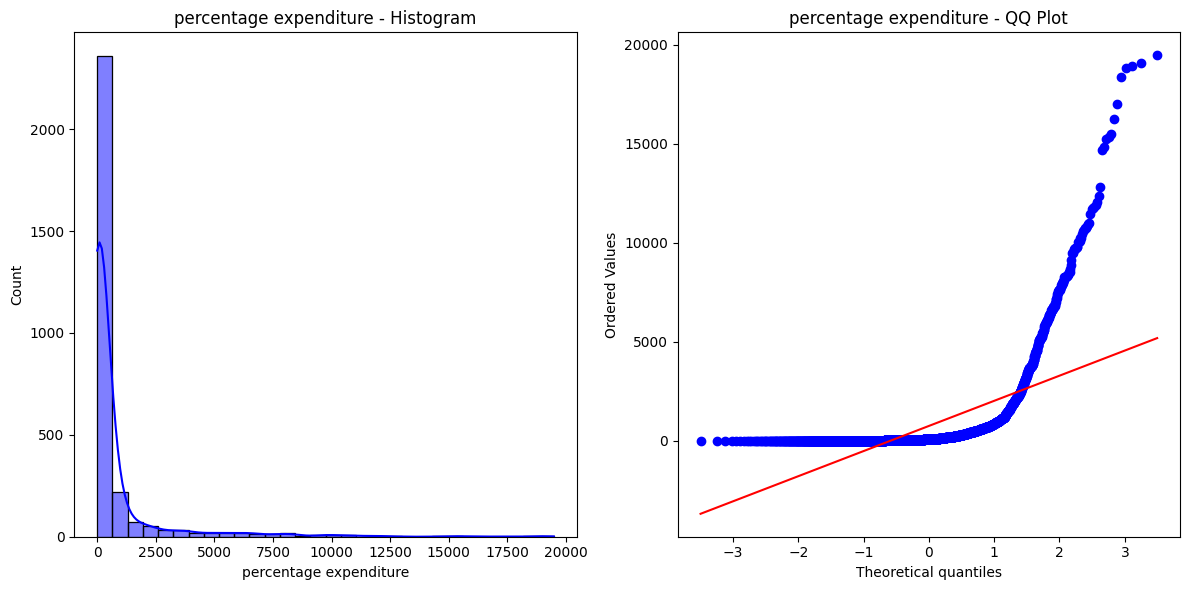

Variable: percentage expenditure
  Skewness: 4.641
  Kurtosis: 26.429
  Shapiro-Wilk Test Statistic: 0.407, p-value: 0.000
--------------------------------------------------


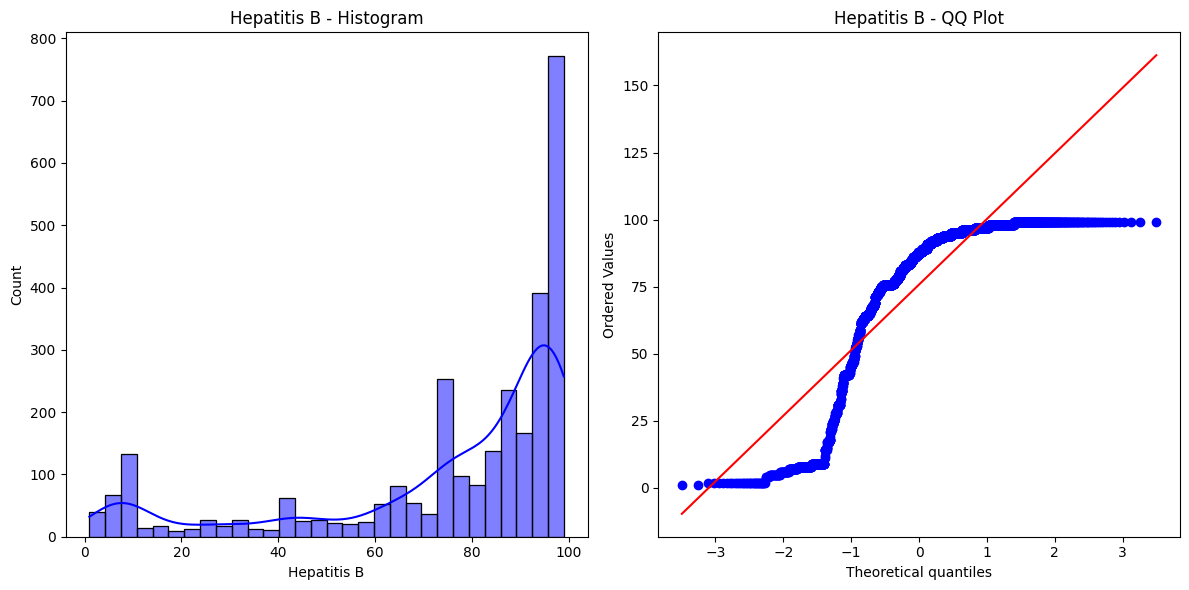

Variable: Hepatitis B
  Skewness: -1.442
  Kurtosis: 0.894
  Shapiro-Wilk Test Statistic: 0.767, p-value: 0.000
--------------------------------------------------


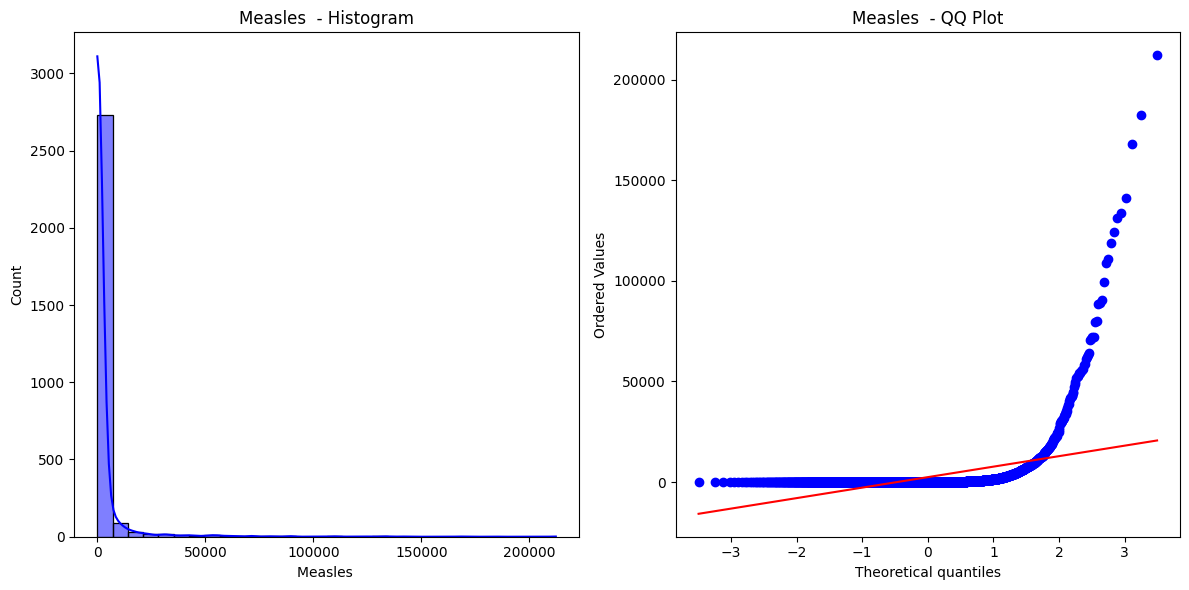

Variable: Measles 
  Skewness: 9.420
  Kurtosis: 114.271
  Shapiro-Wilk Test Statistic: 0.207, p-value: 0.000
--------------------------------------------------


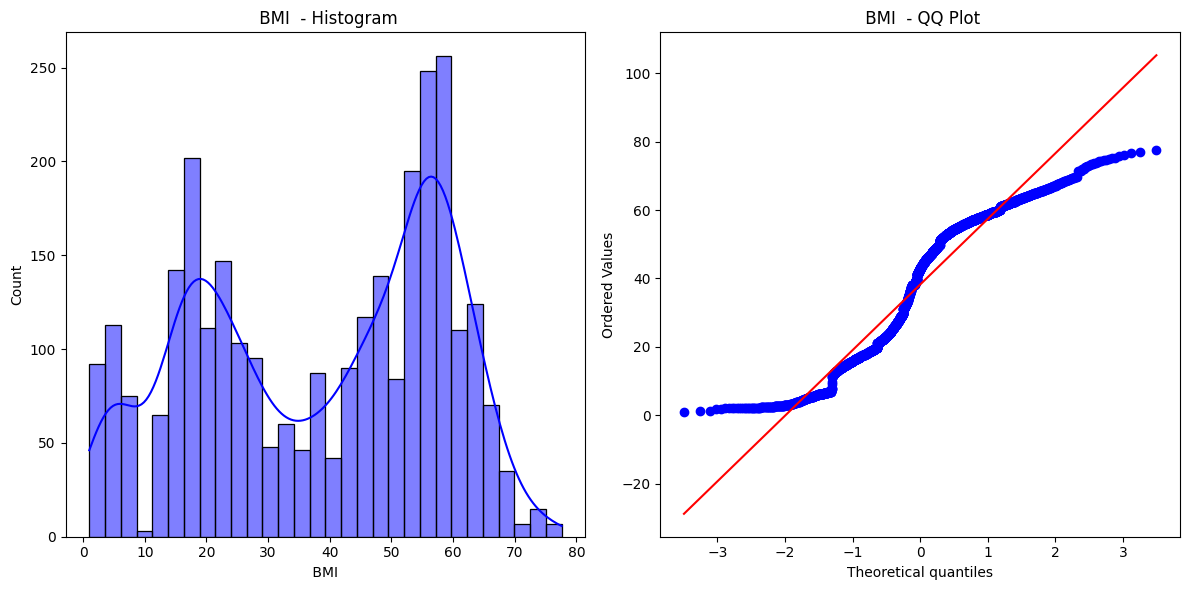

Variable:  BMI 
  Skewness: -0.232
  Kurtosis: -1.294
  Shapiro-Wilk Test Statistic: 0.930, p-value: 0.000
--------------------------------------------------


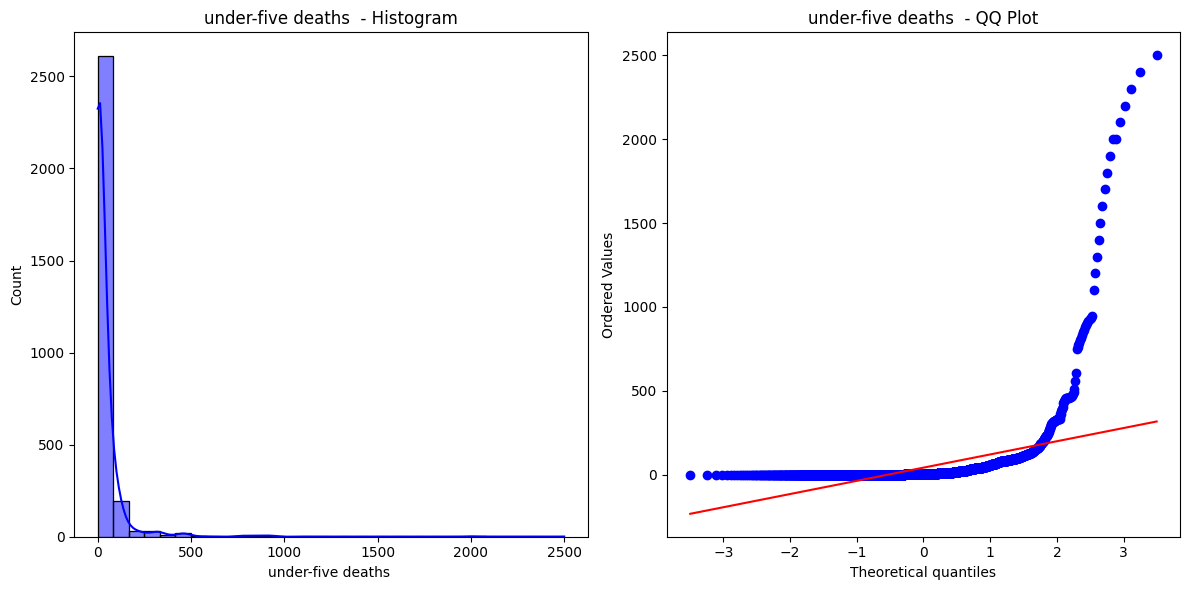

Variable: under-five deaths 
  Skewness: 9.475
  Kurtosis: 109.200
  Shapiro-Wilk Test Statistic: 0.241, p-value: 0.000
--------------------------------------------------


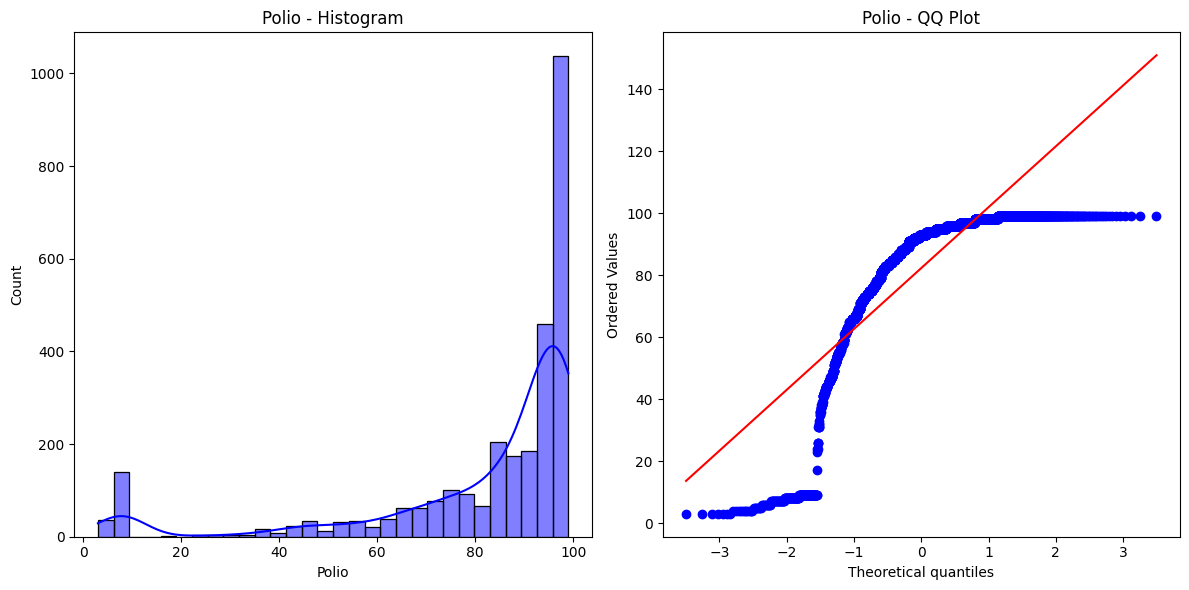

Variable: Polio
  Skewness: -2.065
  Kurtosis: 3.607
  Shapiro-Wilk Test Statistic: 0.690, p-value: 0.000
--------------------------------------------------


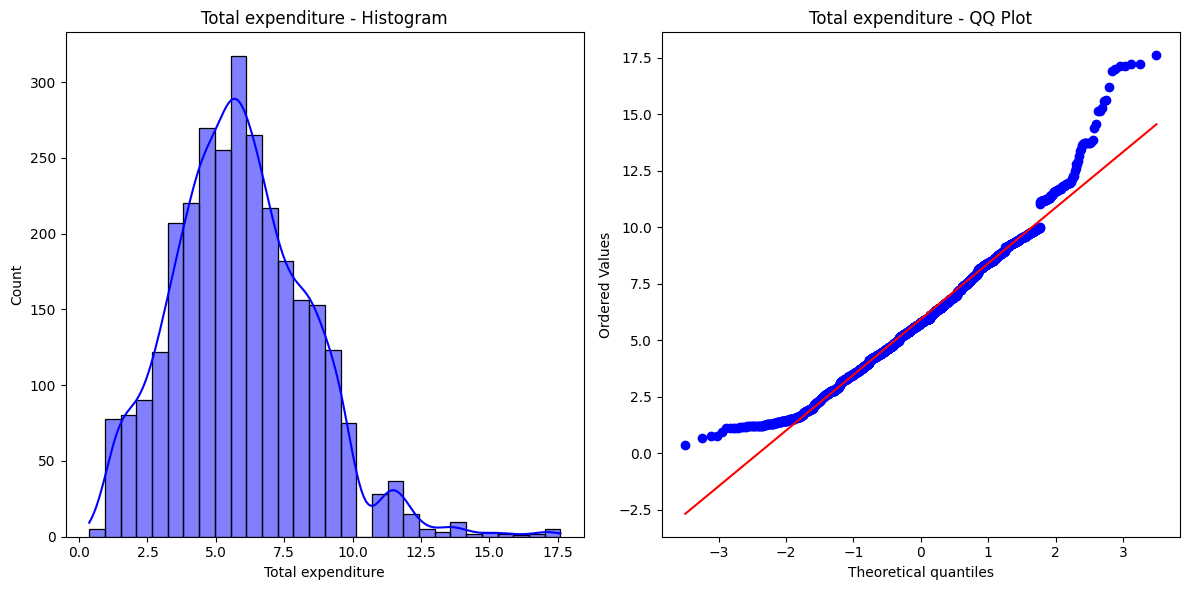

Variable: Total expenditure
  Skewness: 0.589
  Kurtosis: 1.025
  Shapiro-Wilk Test Statistic: 0.978, p-value: 0.000
--------------------------------------------------


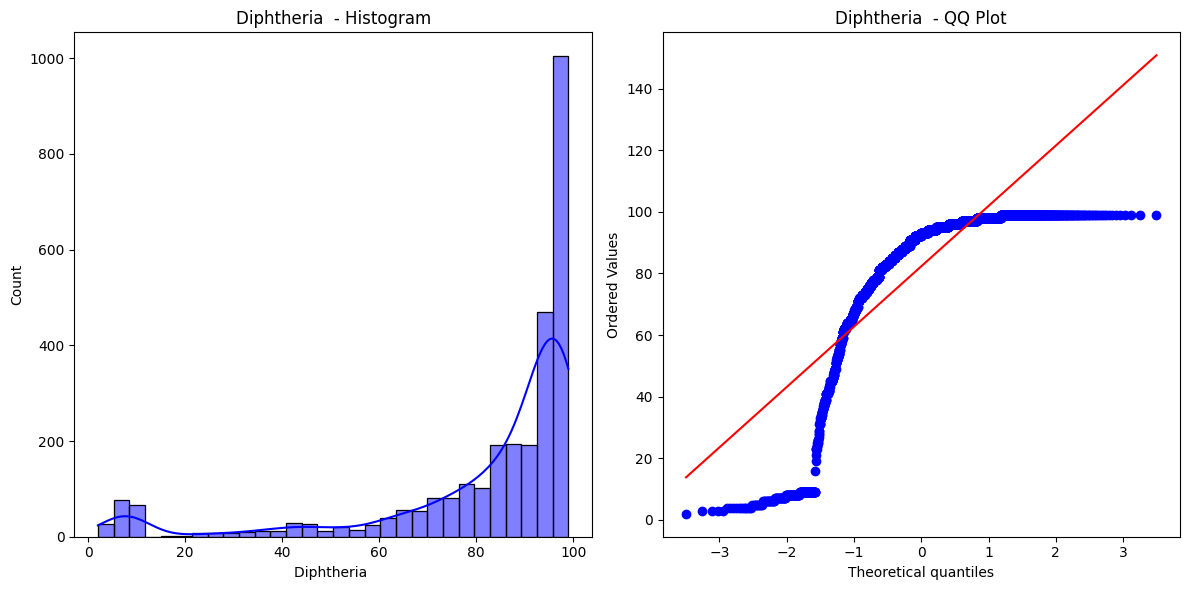

Variable: Diphtheria 
  Skewness: -2.078
  Kurtosis: 3.594
  Shapiro-Wilk Test Statistic: 0.686, p-value: 0.000
--------------------------------------------------


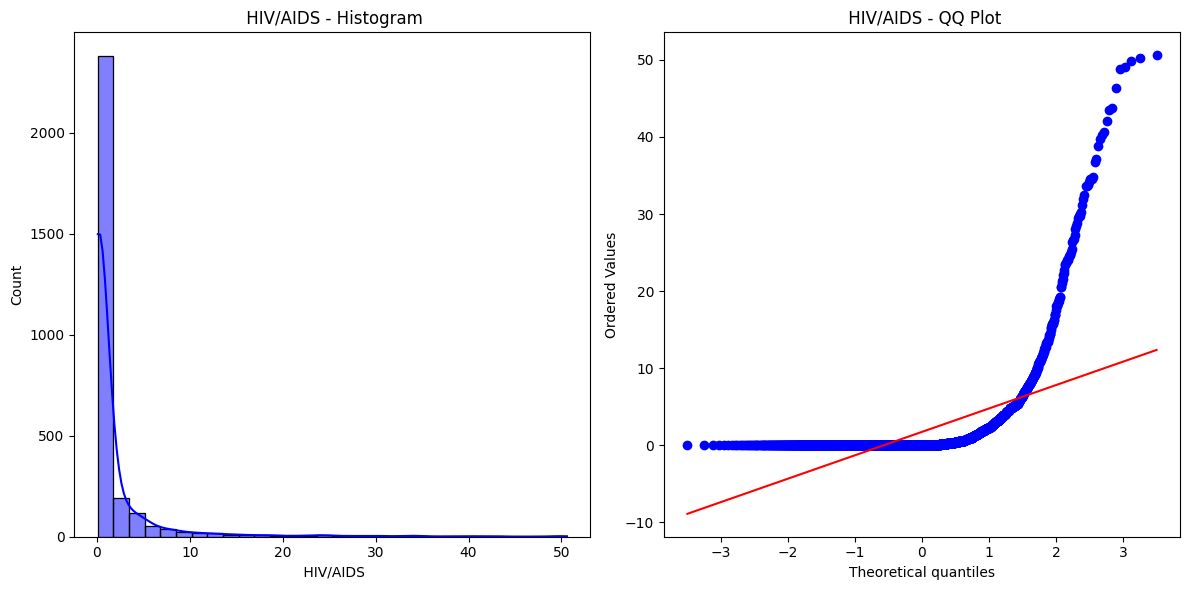

Variable:  HIV/AIDS
  Skewness: 5.384
  Kurtosis: 34.705
  Shapiro-Wilk Test Statistic: 0.357, p-value: 0.000
--------------------------------------------------


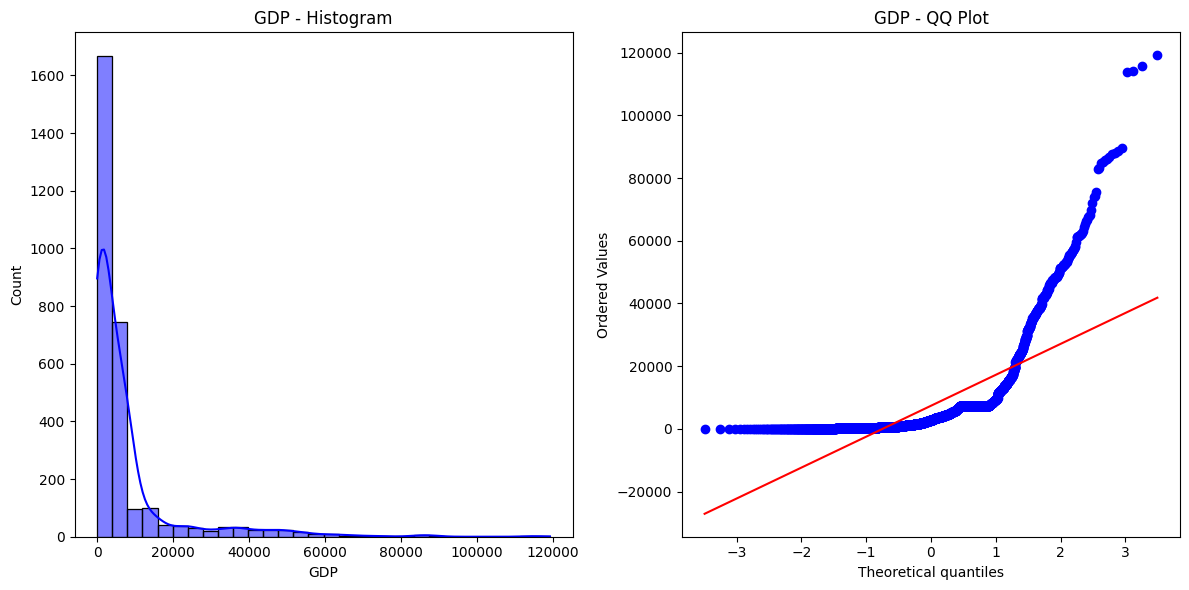

Variable: GDP
  Skewness: 3.478
  Kurtosis: 14.981
  Shapiro-Wilk Test Statistic: 0.559, p-value: 0.000
--------------------------------------------------


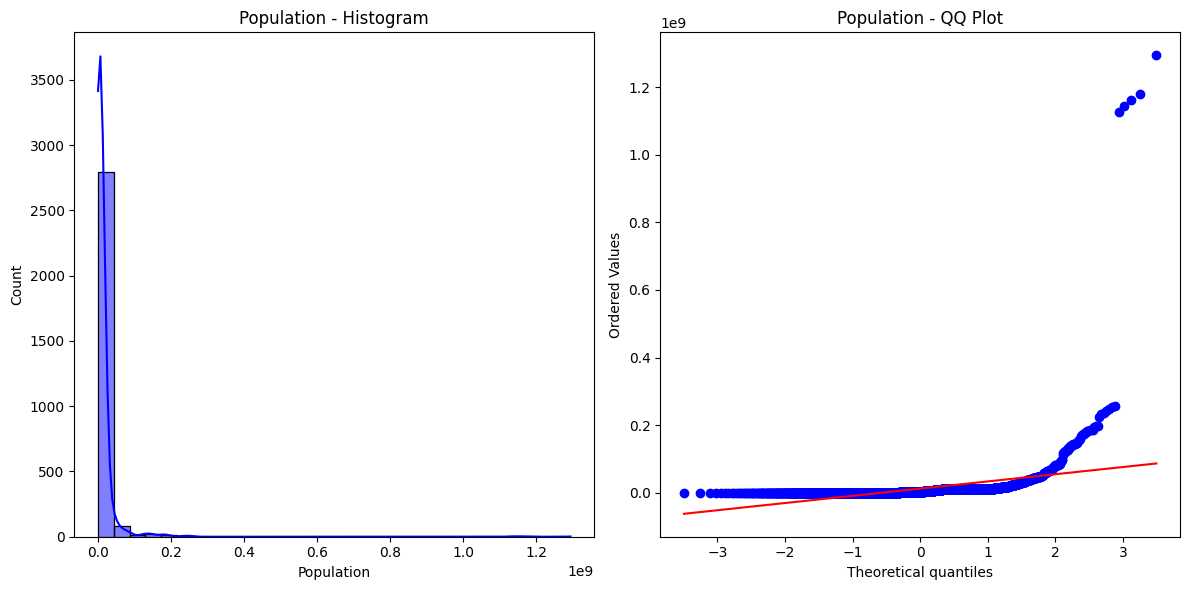

Variable: Population
  Skewness: 18.001
  Kurtosis: 381.697
  Shapiro-Wilk Test Statistic: 0.157, p-value: 0.000
--------------------------------------------------


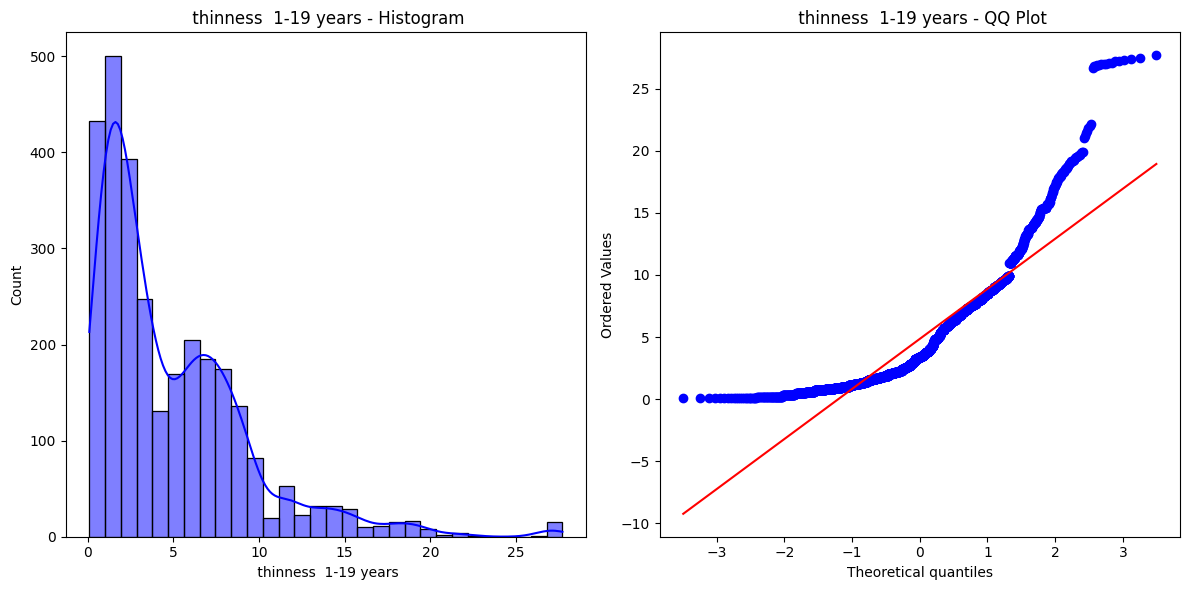

Variable:  thinness  1-19 years
  Skewness: 1.719
  Kurtosis: 4.034
  Shapiro-Wilk Test Statistic: 0.839, p-value: 0.000
--------------------------------------------------


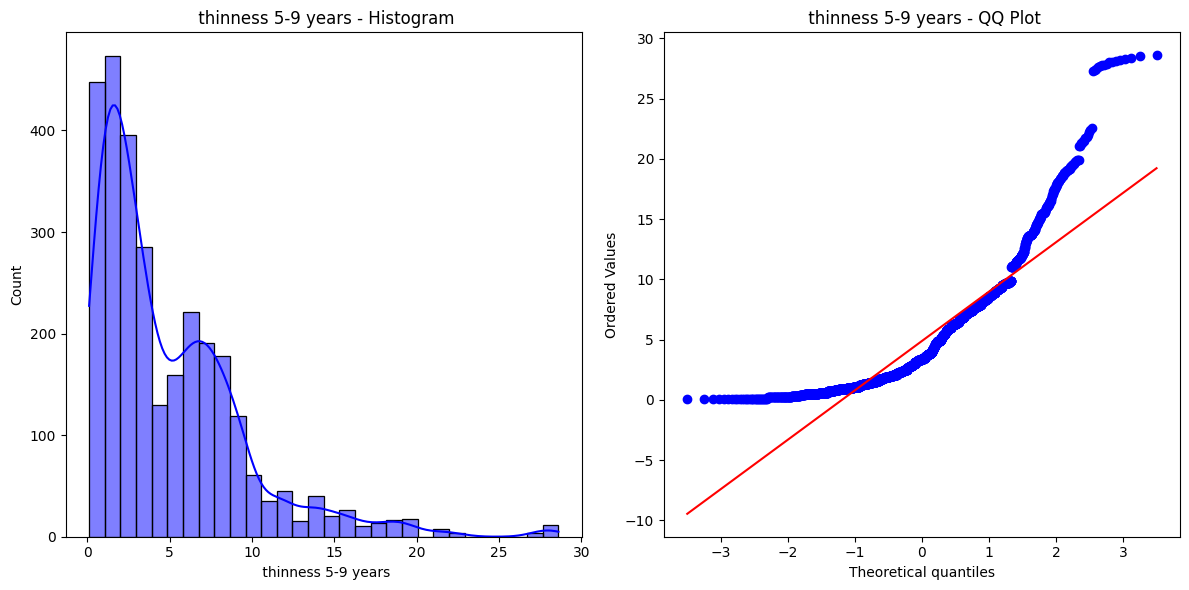

Variable:  thinness 5-9 years
  Skewness: 1.785
  Kurtosis: 4.426
  Shapiro-Wilk Test Statistic: 0.835, p-value: 0.000
--------------------------------------------------


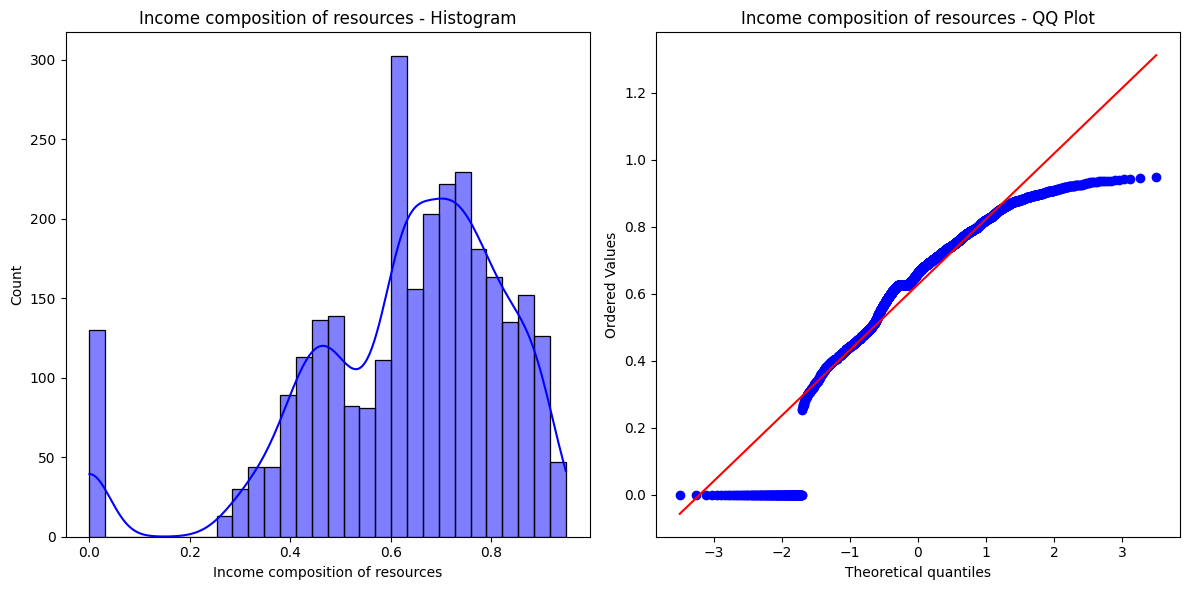

Variable: Income composition of resources
  Skewness: -1.174
  Kurtosis: 1.637
  Shapiro-Wilk Test Statistic: 0.908, p-value: 0.000
--------------------------------------------------


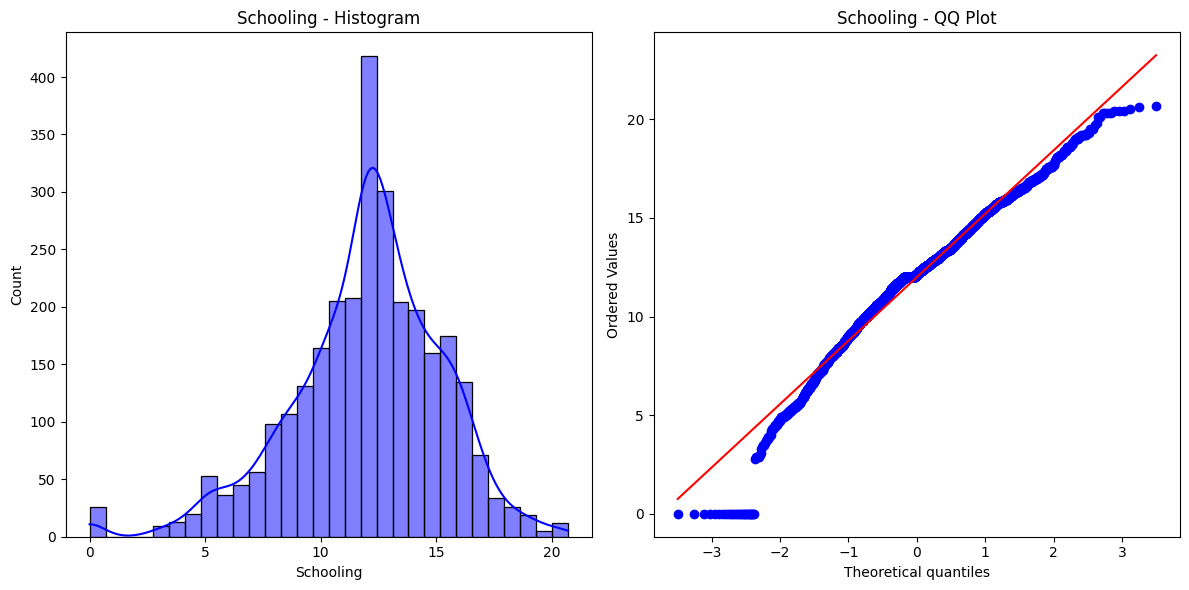

Variable: Schooling
  Skewness: -0.600
  Kurtosis: 1.057
  Shapiro-Wilk Test Statistic: 0.976, p-value: 0.000
--------------------------------------------------
                           Variable   Skewness    Kurtosis  \
0                  Life expectancy   -0.638278   -0.236126   
1                   Adult Mortality   1.173768    1.743827   
2                     infant deaths   9.766038  115.458023   
3                           Alcohol   0.601766   -0.789861   
4            percentage expenditure   4.641410   26.428591   
5                       Hepatitis B  -1.442283    0.893837   
6                          Measles    9.420461  114.270552   
7                              BMI   -0.231709   -1.294201   
8                under-five deaths    9.474766  109.199678   
9                             Polio  -2.065158    3.606922   
10                Total expenditure   0.589271    1.024992   
11                      Diphtheria   -2.078286    3.593866   
12                         HIV/AI

In [13]:
numeric_columns = [col for col in LEDC.select_dtypes(include=['float64', 'int64']).columns if col != 'Year']

results = []

for col in numeric_columns:

    data = LEDC[col].dropna()

    plt.figure(figsize=(12, 6))

    #hist
    plt.subplot(1, 2, 1)
    sns.histplot(data, kde=True, bins=30, color='blue')
    plt.title(f'{col} - Histogram')

    #qq
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'{col} - QQ Plot')

    plt.tight_layout()
    plt.show()

    # Skewness Kurtosis
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    # Shapiro-Wilk Test
    shapiro_stat, shapiro_p = shapiro(data)

    print(f"Variable: {col}")
    print(f"  Skewness: {skewness:.3f}")
    print(f"  Kurtosis: {kurtosis:.3f}")
    print(f"  Shapiro-Wilk Test Statistic: {shapiro_stat:.3f}, p-value: {shapiro_p:.3f}")
    print("-" * 50)

    results.append({
        'Variable': col,
        'Skewness': skewness,
        'Kurtosis': kurtosis,
        'Shapiro-Wilk Test Statistic': shapiro_stat,
        'Shapiro-Wilk p-value': shapiro_p
    })

results_df = pd.DataFrame(results)
print(results_df)

### 3.3 Visualizations

In [14]:
fig=px.violin(LEDC,x='Status',y='Life expectancy ',color='Status',box=True,title='Life Expectancy Based on Countries Status')
fig.show()

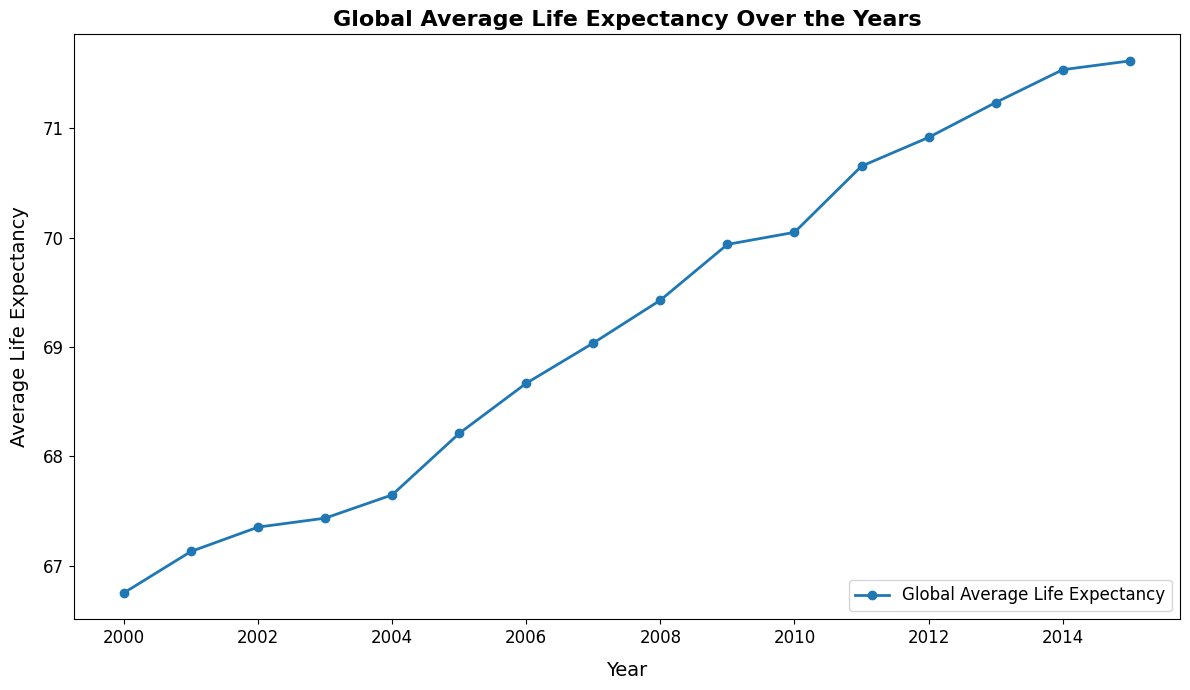

In [15]:
global_avg_life_expectancy = LEDC.groupby('Year')['Life expectancy '].mean()

plt.figure(figsize=(12, 7))
plt.plot(global_avg_life_expectancy.index, global_avg_life_expectancy.values,
         marker='o', linestyle='-', linewidth=2, markersize=6, label='Global Average Life Expectancy')
plt.title('Global Average Life Expectancy Over the Years', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14, labelpad=10)
plt.ylabel('Average Life Expectancy', fontsize=14, labelpad=10)
plt.legend(fontsize=12, loc='lower right')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

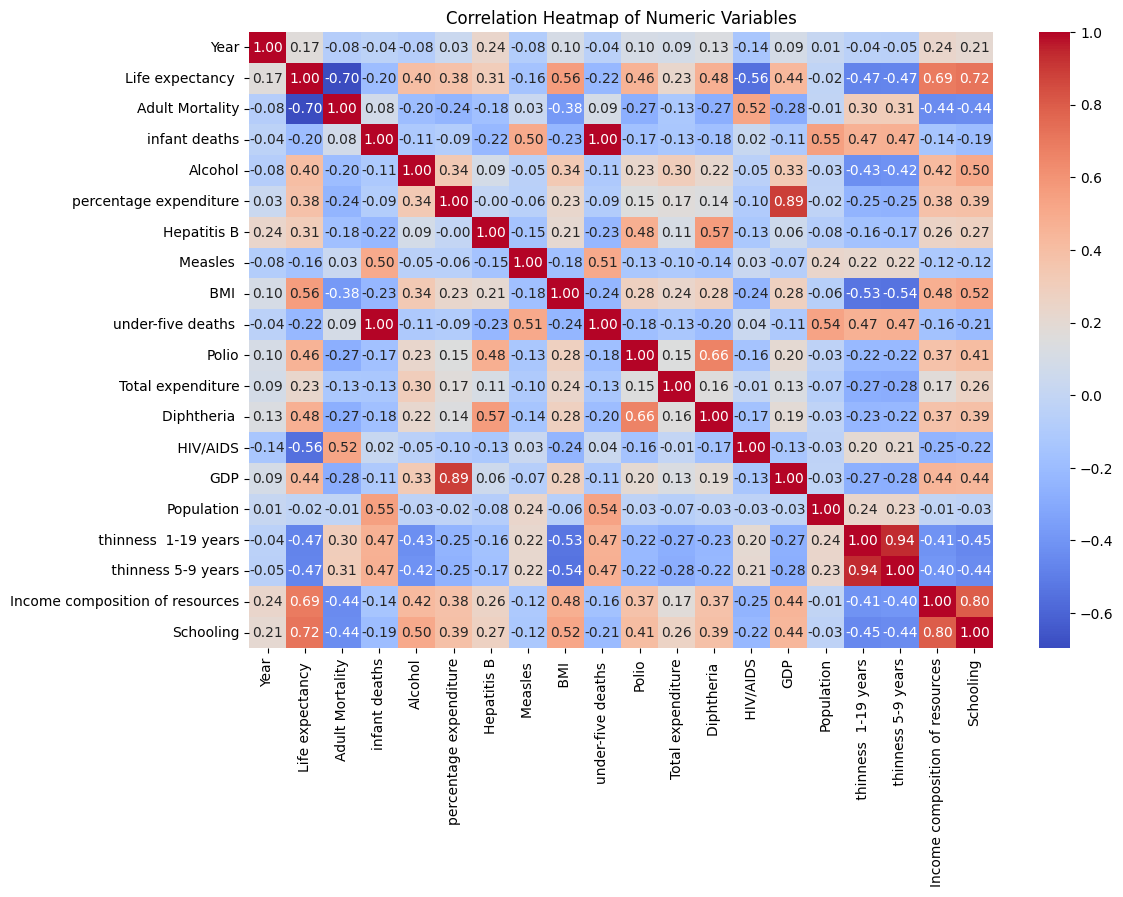

In [16]:
plt.figure(figsize=(12, 8))

numeric_data = LEDC.select_dtypes(include=[np.number])

corr_matrix = numeric_data.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

### 3.4 Outlier Analysis

Boxplots identify outliers across variables. Most are retained as they reflect genuine cross-country disparities. Ten extreme outliers in Life Expectancy are removed due to their deviation from overall trends.

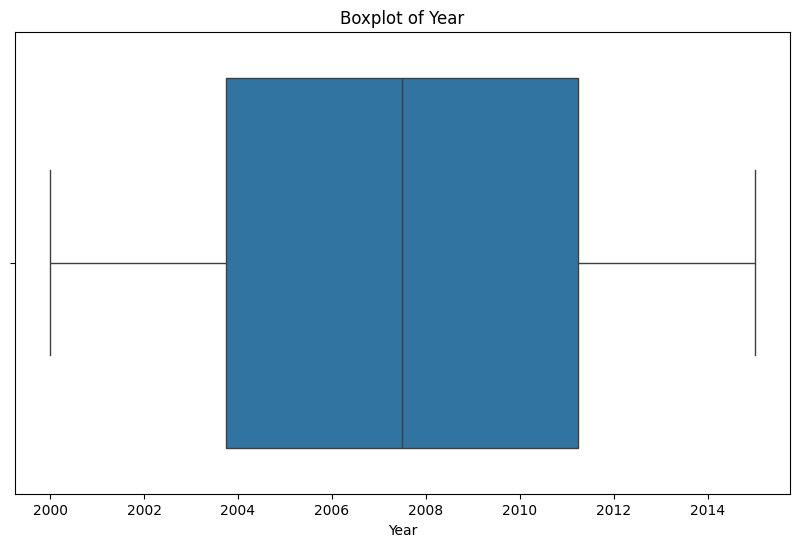

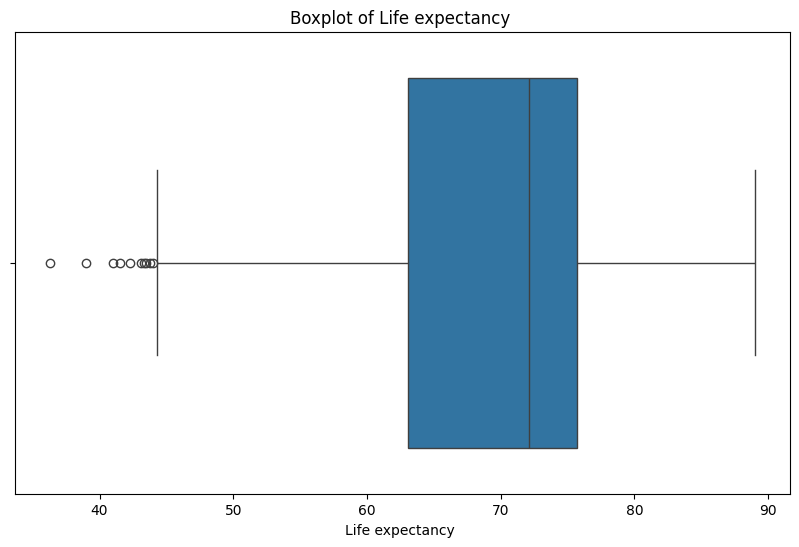

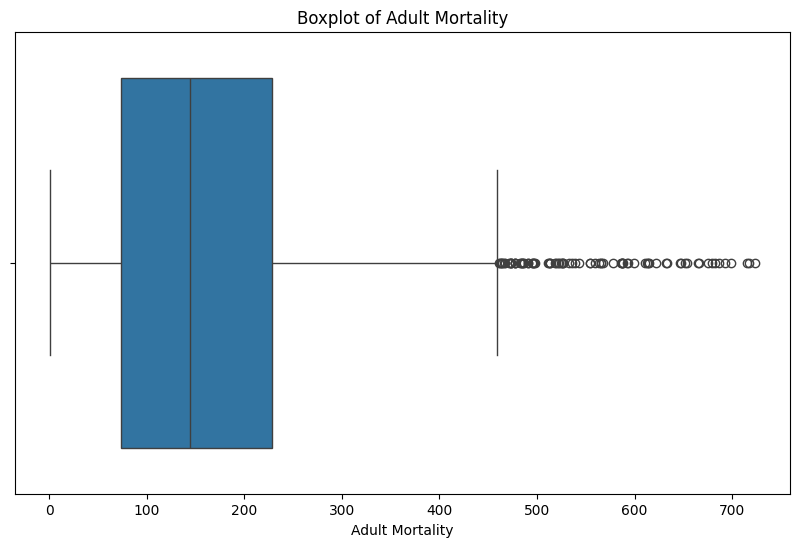

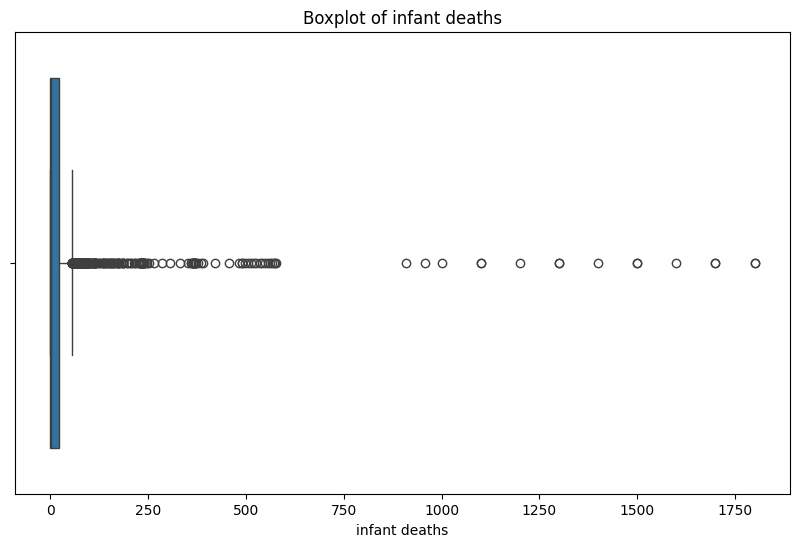

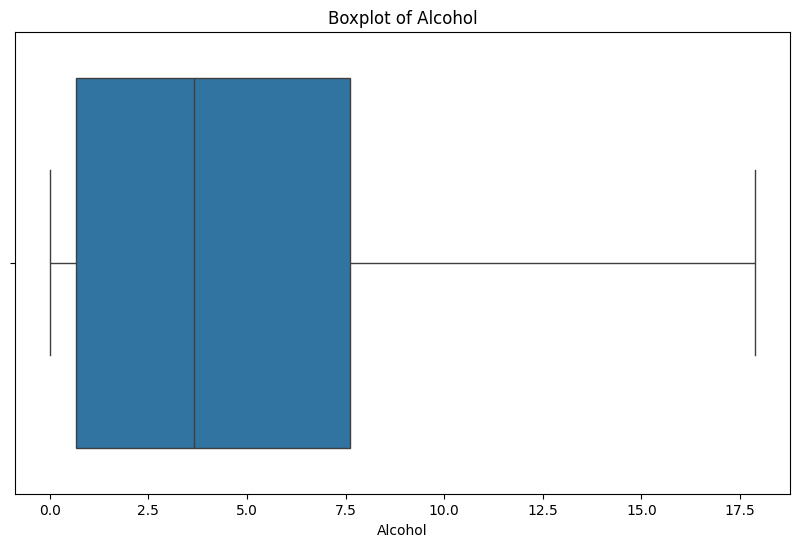

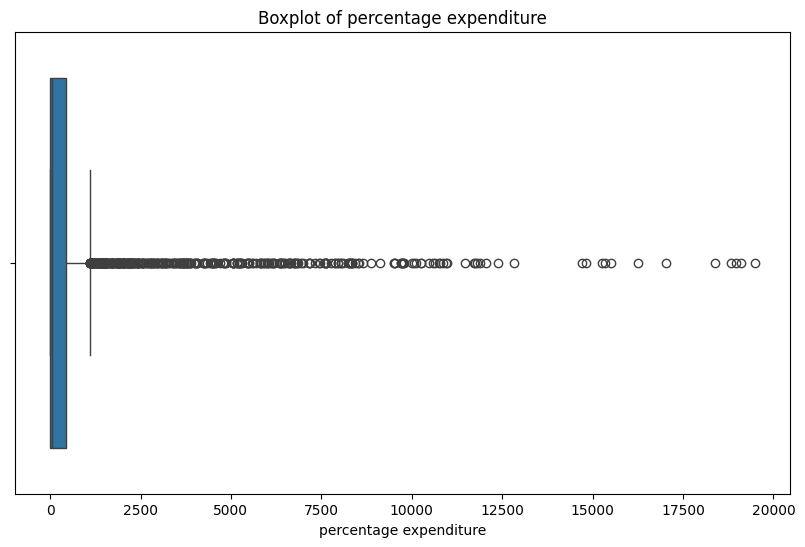

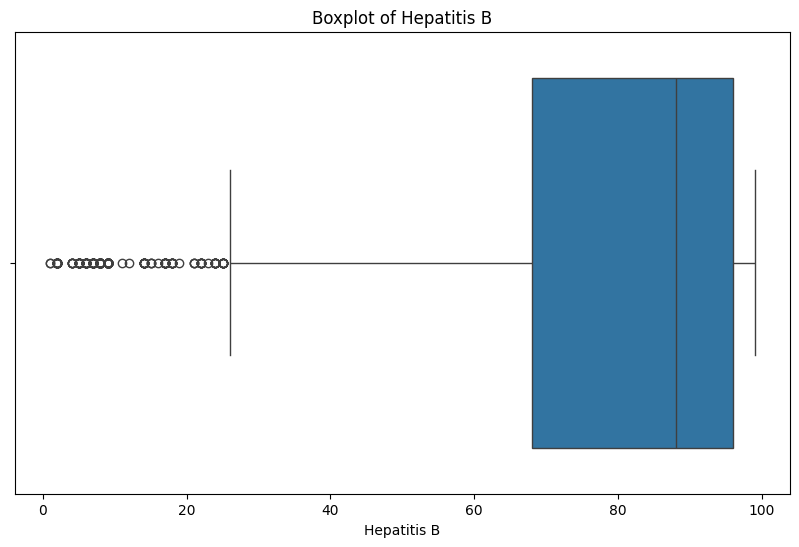

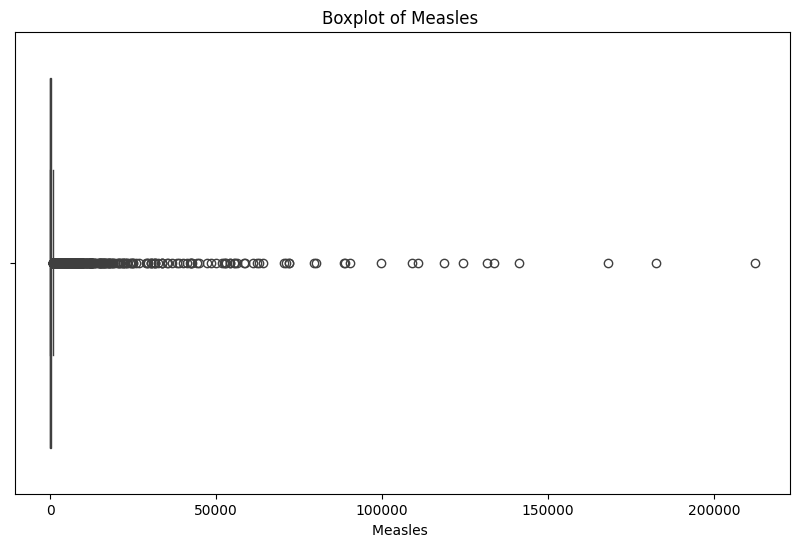

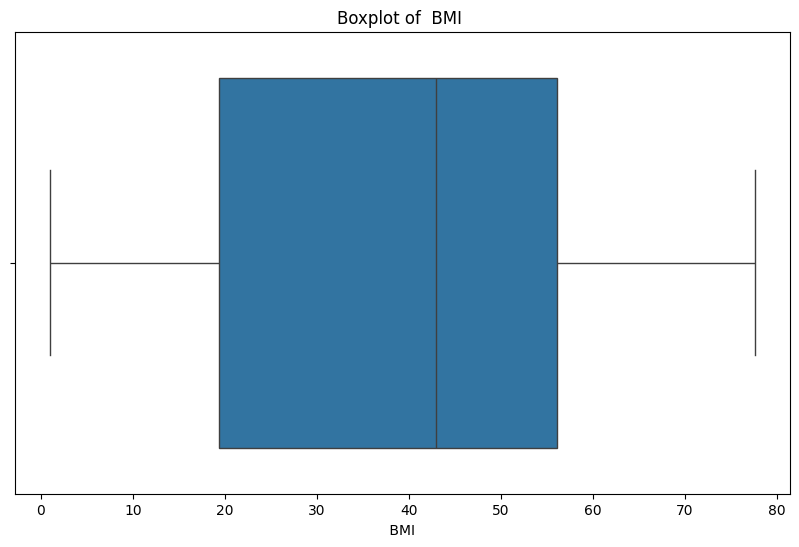

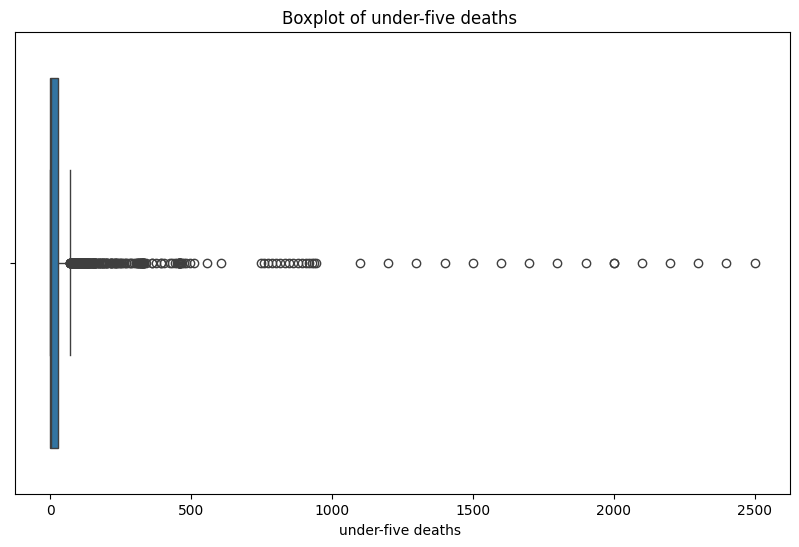

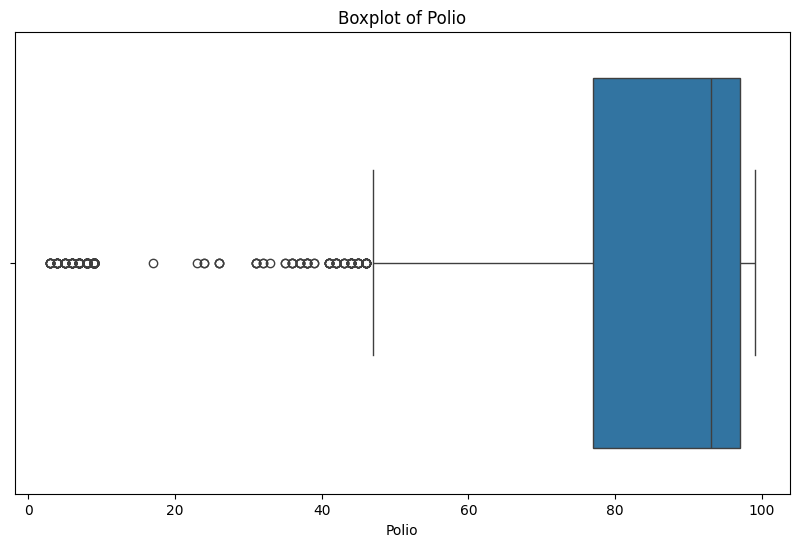

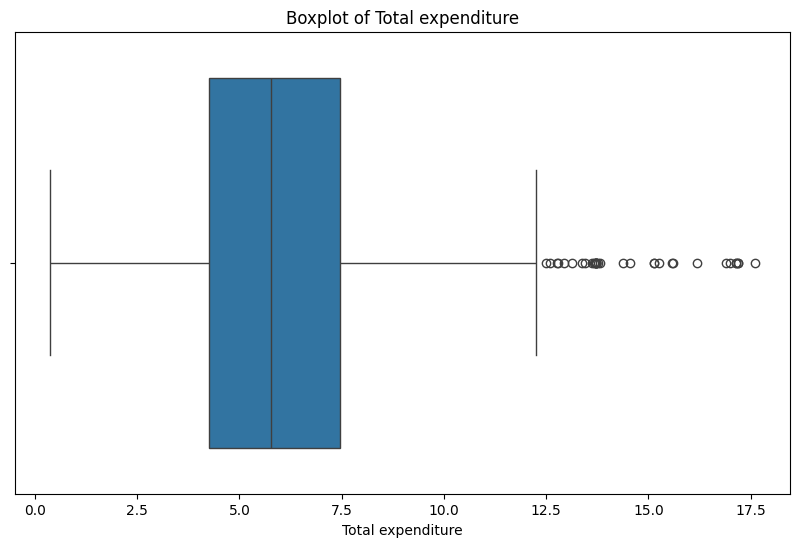

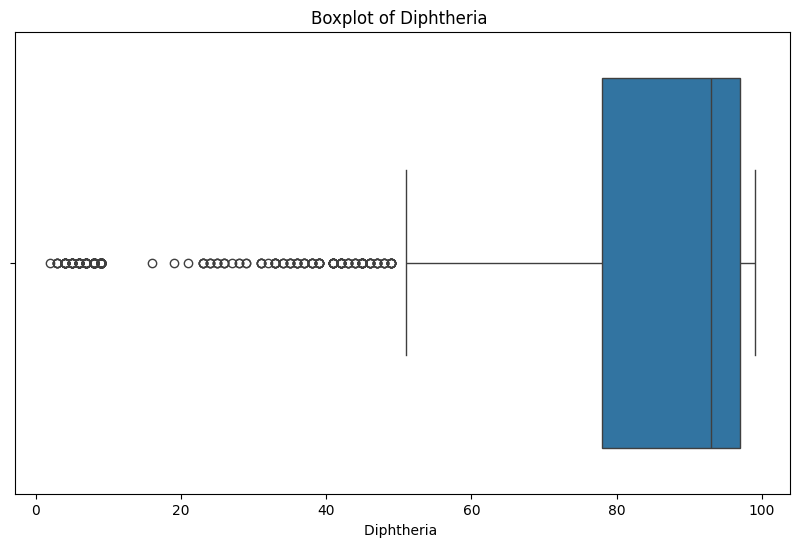

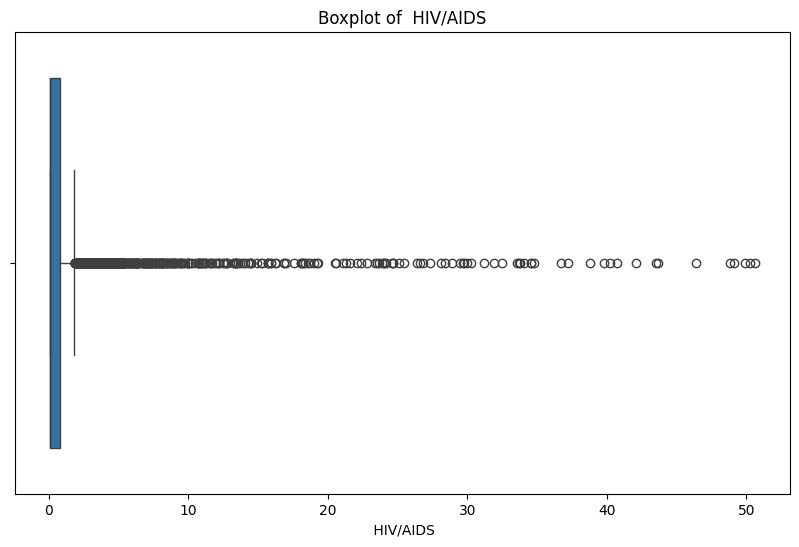

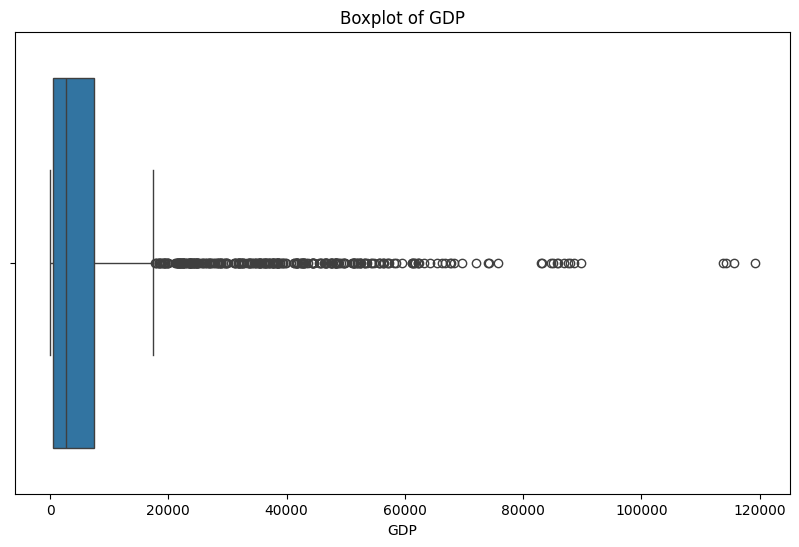

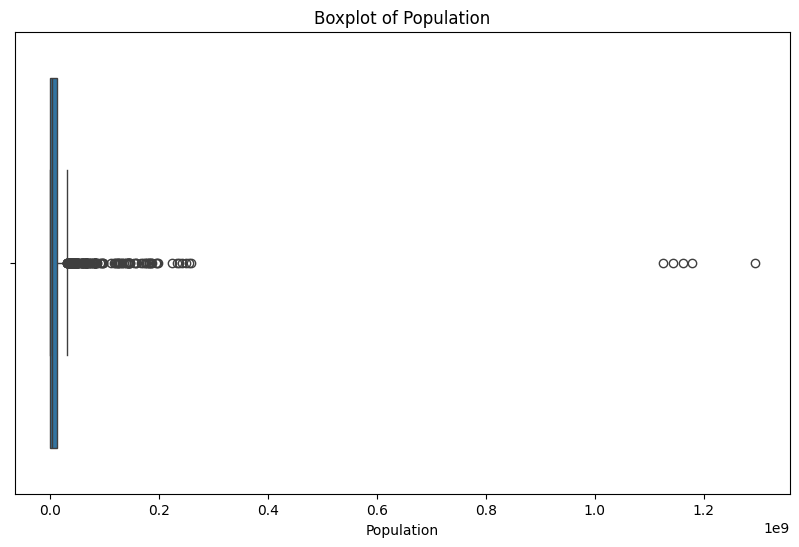

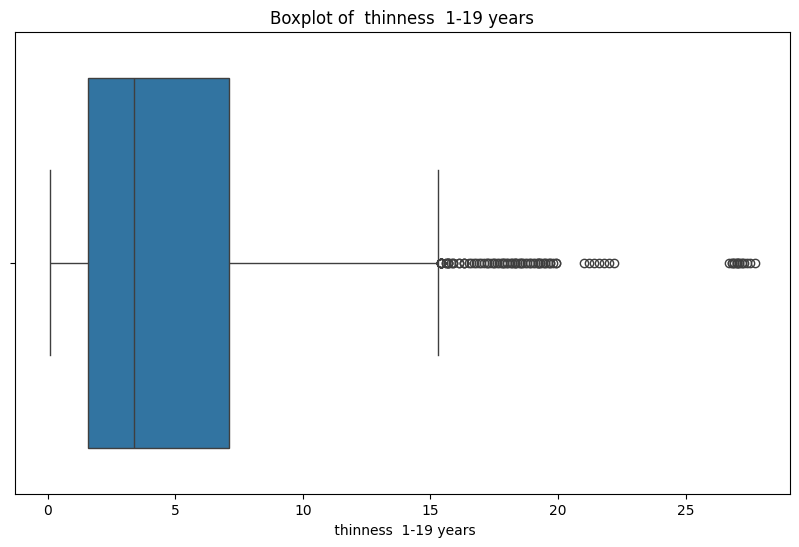

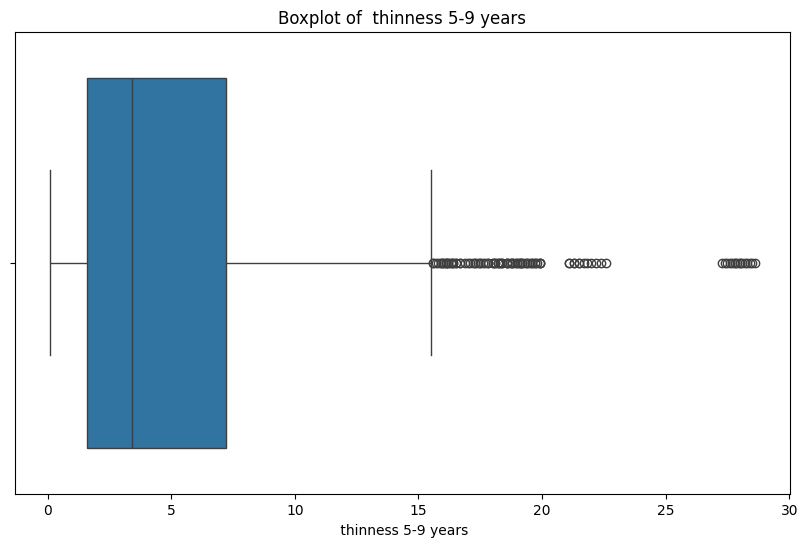

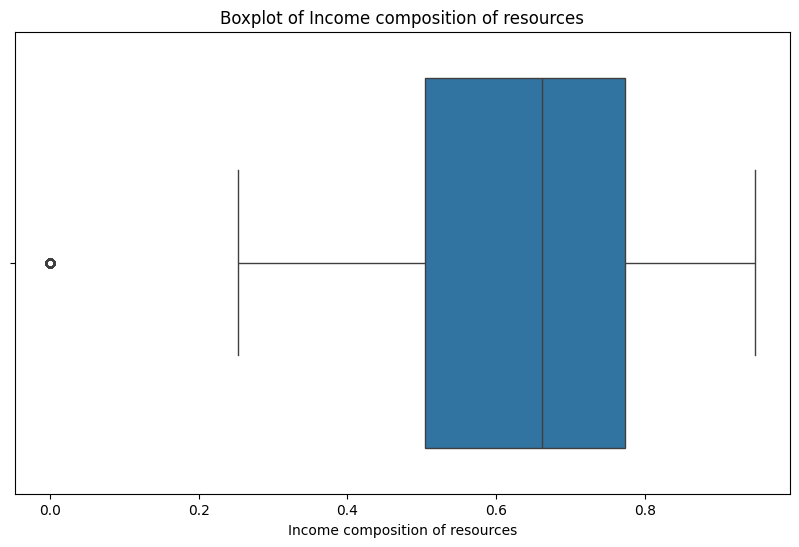

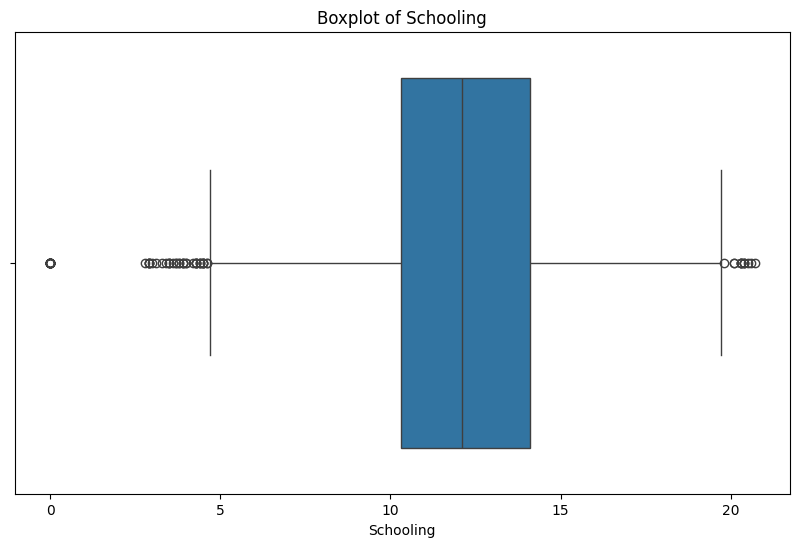

In [17]:
numeric_data = LEDC.select_dtypes(include=[np.number])
for column in numeric_data.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=numeric_data[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [18]:
outlier_info_life_expectancy = {}

column = "Life expectancy "

Q1 = numeric_data[column].quantile(0.25)
Q3 = numeric_data[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_life_expectancy = numeric_data[(numeric_data[column] < lower_bound) | (numeric_data[column] > upper_bound)]
outlier_info_life_expectancy[column] = outliers_life_expectancy

outliers_life_expectancy

outlier_indices = outliers_life_expectancy.index
LEDC = LEDC.drop(index=outlier_indices)

In [19]:
outlier_indices

Index([1127, 1583, 1584, 1585, 2307, 2308, 2309, 2311, 2312, 2921], dtype='int64')

## 4. Modeling

All three models use the same feature set after removing highly collinear variables: `Income composition of resources` (r=0.80 with Schooling), `under-five deaths` (r=0.99 with infant deaths), and `thinness 5-9 years` (r=0.94 with thinness 1-19 years).

In [20]:
LED_model = LEDC.drop(columns=['GDP', 'Income composition of resources','Year','Country','under-five deaths ',' thinness 5-9 years'])
LED_model['Status'] = LEDC['Status'].map({'Developed': 1, 'Developing': 0})
print(LED_model['Status'].unique())

[0 1]


In [21]:
LED_model.columns

Index(['Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'Population',
       ' thinness  1-19 years', 'Schooling'],
      dtype='object')

### 4.1 Model 1: OLS Linear Regression (R² = 0.802)

OLS regression identifies Schooling as the strongest positive predictor of life expectancy, with HIV/AIDS and Adult Mortality as the most significant negative drivers. The model explains 80.2% of variance in life expectancy.

In [22]:
final_features = [col for col in LED_model.columns if col != 'Life expectancy ']
X_final = LED_model[final_features]
y_final = LED_model['Life expectancy ']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

final_model = LinearRegression()
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_final)

print(f"R²: {final_r2}")

R²: 0.8021315469254556


In [23]:
X_final_const = sm.add_constant(X_final)
ols_model = sm.OLS(y_final, X_final_const).fit()

coefficients = pd.DataFrame({
    'Variable': X_final_const.columns,
    'Coefficient': ols_model.params,
    'P-Value': ols_model.pvalues
})

coefficients.reset_index(drop=True, inplace=True)
coefficients.sort_values(by="P-Value", ascending=True, inplace=True)

def significance_stars(p_value):
    if p_value <= 0.001:
        return '***'
    elif p_value <= 0.01:
        return '**'
    elif p_value <= 0.05:
        return '*'
    else:
        return ''

coefficients['Significance'] = coefficients['P-Value'].apply(significance_stars)

print(coefficients)

                  Variable   Coefficient        P-Value Significance
0                    const  5.387840e+01   0.000000e+00          ***
15               Schooling  9.445918e-01  2.247077e-148          ***
12                HIV/AIDS -4.894595e-01  2.663558e-141          ***
2          Adult Mortality -2.075073e-02  1.213812e-126          ***
11             Diphtheria   4.789618e-02   5.133939e-23          ***
8                     BMI   4.908926e-02   5.609090e-22          ***
5   percentage expenditure  3.055152e-04   1.243460e-11          ***
1                   Status  1.662484e+00   2.581786e-09          ***
9                    Polio  2.454180e-02   7.192064e-08          ***
7                 Measles  -3.263740e-05   3.222698e-05          ***
14    thinness  1-19 years -7.998063e-02   1.201588e-03           **
13              Population  3.399621e-09   4.872196e-02            *
10       Total expenditure  6.649855e-02   4.954483e-02            *
4                  Alcohol  3.1264

### 4.2 Model 2: Random Forest Regressor (R² = 0.958)

Random Forest achieves substantially higher predictive accuracy (R²=0.958, RMSE=1.96), ranking HIV/AIDS (importance=0.590) and Adult Mortality (0.205) as the top features — a different emphasis than the linear model, which highlighted Schooling. This contrast reflects the non-linear, threshold-based relationships the forest captures.

In [24]:
X = X_final
y = y_final

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R²: {rf_r2}")
print(f"Random Forest RMSE: {rf_rmse}")

Random Forest R²: 0.9577600260625106
Random Forest RMSE: 1.9554427782229047


In [25]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

                   Feature  Importance
11                HIV/AIDS    0.590487
1          Adult Mortality    0.204857
14               Schooling    0.088909
13    thinness  1-19 years    0.027226
7                     BMI     0.023597
2            infant deaths    0.015951
3                  Alcohol    0.012125
4   percentage expenditure    0.006327
9        Total expenditure    0.005914
8                    Polio    0.004883
10             Diphtheria     0.004404
6                 Measles     0.004346
12              Population    0.003877
0                   Status    0.003827
5              Hepatitis B    0.003270


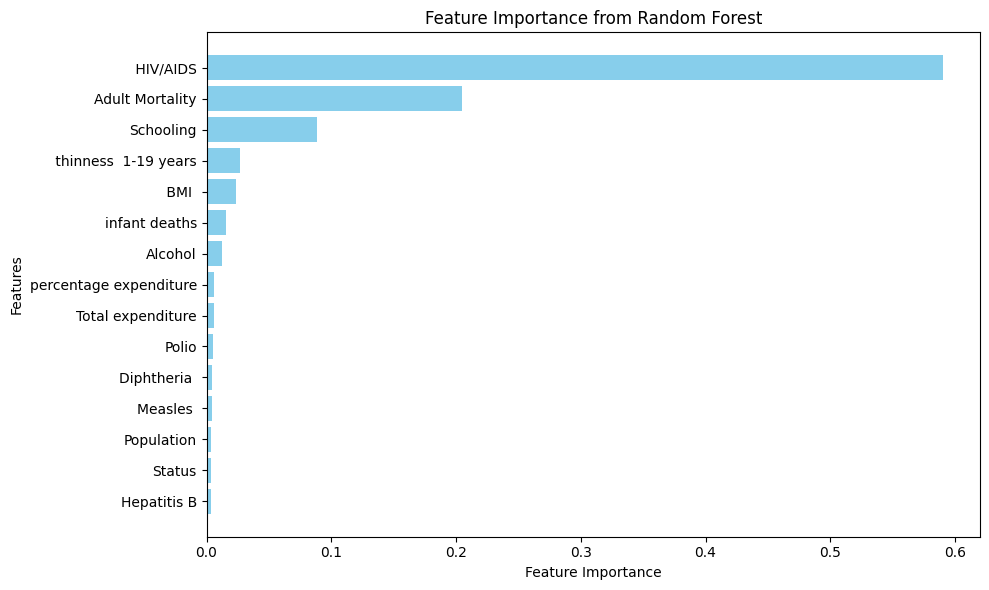

In [26]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Model 3: Interaction Effects (Status × Schooling, Status × Immunization)

I add interaction terms to test whether the effects of education and immunization on life expectancy differ between developed and developing countries. Both interactions are statistically significant: schooling and immunization have stronger positive effects in developing countries, suggesting diminishing returns in countries with already-high baseline infrastructure.

In [27]:
X_Inter = X_final

X_Inter['Status_Schooling'] = X_final['Status'] * X_final['Schooling']
X_Inter['Status_Immunization'] = X_final['Status'] * X_final['Polio']

X_Inter_const = sm.add_constant(X_Inter)
model_Inter = sm.OLS(y_final, X_Inter_const).fit()

coefficients_model_Inter = pd.DataFrame({
    'Variable': X_Inter_const.columns,
    'Coefficient': model_Inter.params,
    'P-Value': model_Inter.pvalues
})

coefficients_model_Inter.reset_index(drop=True, inplace=True)
coefficients_model_Inter.sort_values(by="P-Value", ascending=True, inplace=True)

coefficients_model_Inter['Significance'] = coefficients_model_Inter['P-Value'].apply(significance_stars)

print(coefficients_model_Inter)

                  Variable   Coefficient        P-Value Significance
0                    const  5.335217e+01   0.000000e+00          ***
15               Schooling  1.011695e+00  7.024744e-150          ***
12                HIV/AIDS -4.883375e-01  3.414002e-142          ***
2          Adult Mortality -2.041785e-02  7.582890e-124          ***
11             Diphtheria   4.707974e-02   1.882411e-22          ***
8                     BMI   4.700964e-02   2.222775e-20          ***
5   percentage expenditure  3.610371e-04   3.708496e-15          ***
1                   Status  1.444089e+01   1.067273e-09          ***
16        Status_Schooling -5.810673e-01   1.001276e-08          ***
9                    Polio  2.561489e-02   2.587020e-08          ***
7                 Measles  -3.259653e-05   2.962676e-05          ***
14    thinness  1-19 years -7.901263e-02   1.289098e-03           **
17     Status_Immunization -4.228055e-02   1.624507e-02            *
13              Population  3.2494

## 5. Key Findings

| Model | R² | Key Finding |
|---|---|---|
| OLS Linear Regression | 0.802 | Schooling strongest positive predictor; HIV/AIDS most negative |
| Random Forest | 0.958 | HIV/AIDS dominates feature importance (0.590); non-linear effects captured |
| Interaction Model | ~0.804 | Schooling and immunization have stronger effects in developing countries |

The two models agree that HIV/AIDS prevalence and adult mortality are the most critical negative determinants of life expectancy globally. The interaction model adds nuance: interventions in education and healthcare are disproportionately effective in developing countries, pointing to where policy investment yields the greatest return.